# Selfsupervised learning and Clustering

In [1]:
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import pandas as pd
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import numpy as np
import hdbscan
from sklearn.decomposition import PCA
import umap

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

encoder = models.resnet18(weights=None)
encoder.conv1 = nn.Conv2d(1, 64, 7, 2, 3)
encoder.fc = nn.Identity()  # wichtig: kein classification head
encoder = encoder.to(device)

Using device: mps


In [3]:
def energy_shift(x, max_shift=3):
    """
    Kleine Energieverschiebung simuliert Drift im Analyzer / Kalibrierung.
    max_shift: Anzahl Pixel
    """
    shift = np.random.randint(-max_shift, max_shift + 1)

    if shift == 0:
        return x

    # shift entlang Energieachse (axis=0)
    return np.roll(x, shift, axis=0)

In [4]:
def angle_shift(x, max_shift=2):
    """
    Kleine k-Verschiebung.
    max_shift klein halten, um Symmetrie nicht zu zerstören.
    """

    shift = np.random.randint(-max_shift, max_shift + 1)

    if shift == 0:
        return x

    # shift entlang Winkelachse (axis=1)
    x = np.roll(x, shift, axis=1)

    return x

In [5]:
class ARPESAugment(Dataset):

    def __init__(self, h5_path):
        self.h5_path = h5_path

        with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
            data = f["entry/acquisition/data"]
            self.sample_count = data.shape[2]

        self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
        self._data = self._file["entry/acquisition/data"]

    def __len__(self):
        return self.sample_count

    def __getitem__(self, idx):
        self._init_file()
        img = self._data[:, :, idx]
        x1 = np.ascontiguousarray(self.__call__(img))
        x2 = np.ascontiguousarray(self.__call__(img))
        x1 = torch.tensor(x1, dtype=torch.float32).unsqueeze(0)
        x2 = torch.tensor(x2, dtype=torch.float32).unsqueeze(0)
        return x1, x2

    def _init_file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
            self._data = self._file["entry/acquisition/data"]

    def __call__(self, x):

        # random intensity scaling
        x = x * np.random.uniform(0.8, 1.2)

        # noise
        x = x + np.random.normal(0, 0.01, x.shape)

        # random flip (optional)
        #if np.random.rand() > 0.5:
        #    x = np.flip(x, axis=1)

        # 3. kleine Energieverschiebung
        if np.random.rand() < 0.7:
            x = energy_shift(x, max_shift=3)

        # 4. kleine Winkelverschiebung
        if np.random.rand() < 0.7:
            x = angle_shift(x, max_shift=2)


        return x

In [6]:
# labels not used in training, but could be used for evaluation and visualization
labels_df_2 = pd.read_excel('/Users/atimm/Documents/ML/data/Classification_table_Version3.xlsx', usecols=['Resolution'])

# first dataset, small
h5_path = '/users/atimm/Documents/ML/data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'

# second dataset
#h5_path = '/Users/atimm/Documents/ML/data/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5'

In [7]:
full_dataset = ARPESAugment(h5_path)
loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

In [8]:
projector = nn.Sequential(
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 128)
).to(device)

In [9]:
predictor = nn.Sequential(
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 128)
).to(device)

In [10]:
import copy

target_encoder = copy.deepcopy(encoder)
target_projector = copy.deepcopy(projector)

for p in target_encoder.parameters():
    p.requires_grad = False
for p in target_projector.parameters():
    p.requires_grad = False

In [11]:
@torch.no_grad()
def update_target_network(encoder, projector,
                          target_encoder, target_projector,
                          tau=0.99):

    for p, tp in zip(encoder.parameters(), target_encoder.parameters()):
        tp.data = tau * tp.data + (1 - tau) * p.data

    for p, tp in zip(projector.parameters(), target_projector.parameters()):
        tp.data = tau * tp.data + (1 - tau) * p.data

In [12]:
def byol_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()

In [13]:
optimizer = torch.optim.Adam(
    list(encoder.parameters()) +
    list(projector.parameters()) +
    list(predictor.parameters()),
    lr=1e-4
)

## Training loop

In [14]:
for epoch in range(30):

    epoch_loss = 0.0

    for x1, x2 in loader:

        x1, x2 = x1.to(device), x2.to(device)

        # ONLINE network
        z1 = encoder(x1)
        z1 = projector(z1)
        p1 = predictor(z1)

        z2 = encoder(x2)
        z2 = projector(z2)
        p2 = predictor(z2)

        # TARGET network (no grad)
        with torch.no_grad():
            t1 = target_encoder(x1)
            t1 = target_projector(t1)

            t2 = target_encoder(x2)
            t2 = target_projector(t2)

        loss = byol_loss(p1, t2) + byol_loss(p2, t1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_target_network(
            encoder, projector,
            target_encoder, target_projector,
            tau=0.99
        )

        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    #print(f"Epoch {epoch}: loss {loss.item():.4f}")
    print(f"Epoch {epoch}: loss = {epoch_loss:.4f}")

torch.save({
    "encoder": encoder.state_dict(),
    "projector": projector.state_dict(),
    "predictor": predictor.state_dict()
}, "arpes_ssl_byol.pth")

Epoch 0: loss = 2.6738
Epoch 1: loss = 1.9931
Epoch 2: loss = 1.5900
Epoch 3: loss = 1.2509
Epoch 4: loss = 0.9585
Epoch 5: loss = 0.7194
Epoch 6: loss = 0.5346
Epoch 7: loss = 0.3931
Epoch 8: loss = 0.2943
Epoch 9: loss = 0.2254
Epoch 10: loss = 0.1751
Epoch 11: loss = 0.1429
Epoch 12: loss = 0.1215
Epoch 13: loss = 0.1069
Epoch 14: loss = 0.0973
Epoch 15: loss = 0.0879
Epoch 16: loss = 0.0837
Epoch 17: loss = 0.0783
Epoch 18: loss = 0.0745
Epoch 19: loss = 0.0712
Epoch 20: loss = 0.0685
Epoch 21: loss = 0.0668
Epoch 22: loss = 0.0643
Epoch 23: loss = 0.0624
Epoch 24: loss = 0.0614
Epoch 25: loss = 0.0581
Epoch 26: loss = 0.0553
Epoch 27: loss = 0.0531
Epoch 28: loss = 0.0517
Epoch 29: loss = 0.0499


## Embeddings

In [15]:
encoder.eval()

embeddings = []

with torch.no_grad():
    for x1, x2 in loader:
        x = x1.to(device)
        z = encoder(x)
        embeddings.append(z.cpu().numpy())

embeddings = np.vstack(embeddings)

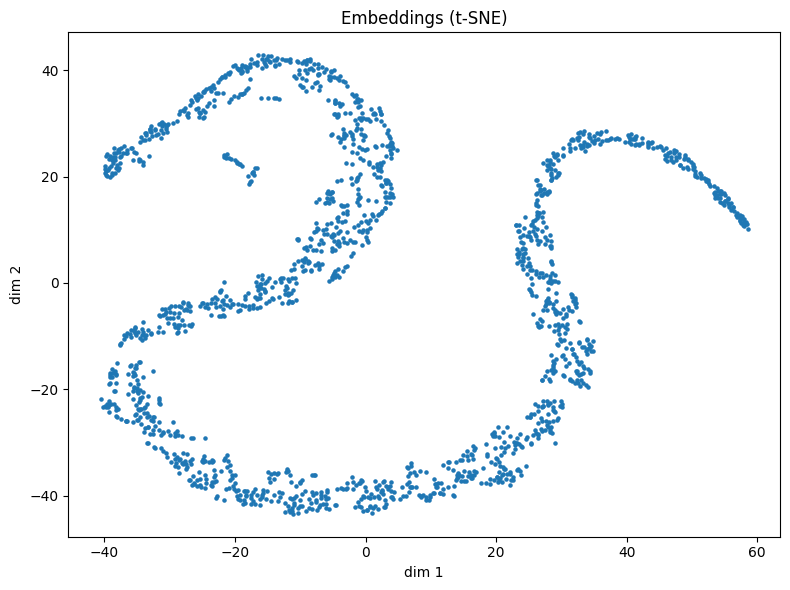

In [16]:
# Visualize embeddings with PCA + t-SNE
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# assemble embeddings (list of arrays per batch)
if 'embeddings' not in globals():
    raise RuntimeError('Variable embeddings not found. Run the embedding extraction cell first.')
emb_arr = np.vstack(embeddings)

# load labels if available
labels_arr = None
#try:
#    labels_arr = np.asarray(y)
#except Exception:
labels_arr = None

# align lengths
n = emb_arr.shape[0]
if labels_arr is not None:
    labels_arr = labels_arr[:n]

# PCA then t-SNE for speed
pca = PCA(n_components=min(50, emb_arr.shape[1]))
emb_p = pca.fit_transform(emb_arr)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
emb_2d = tsne.fit_transform(emb_p)

plt.figure(figsize=(8,6))
if labels_arr is None:
    plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5)
else:
    sc = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels_arr, cmap='tab10', s=6)
    plt.colorbar(sc, label='label')
plt.title('Embeddings (t-SNE)')
plt.xlabel('dim 1')
plt.ylabel('dim 2')
plt.tight_layout()
plt.show()

## Clustering
Clustering via 4 different methods, KMeans and HDBSCAN+UMAP seem to generate the best results, highly dependent on the variables used

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Gefundene Cluster: 8
Noise-Punkte: 155


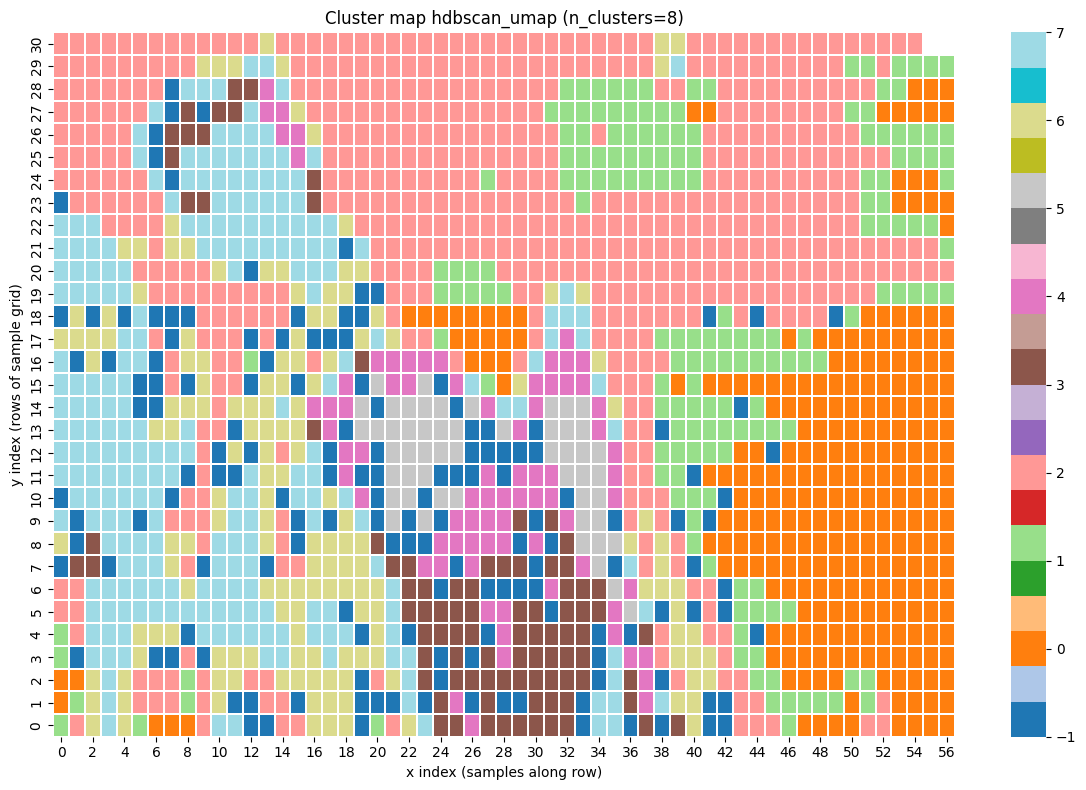

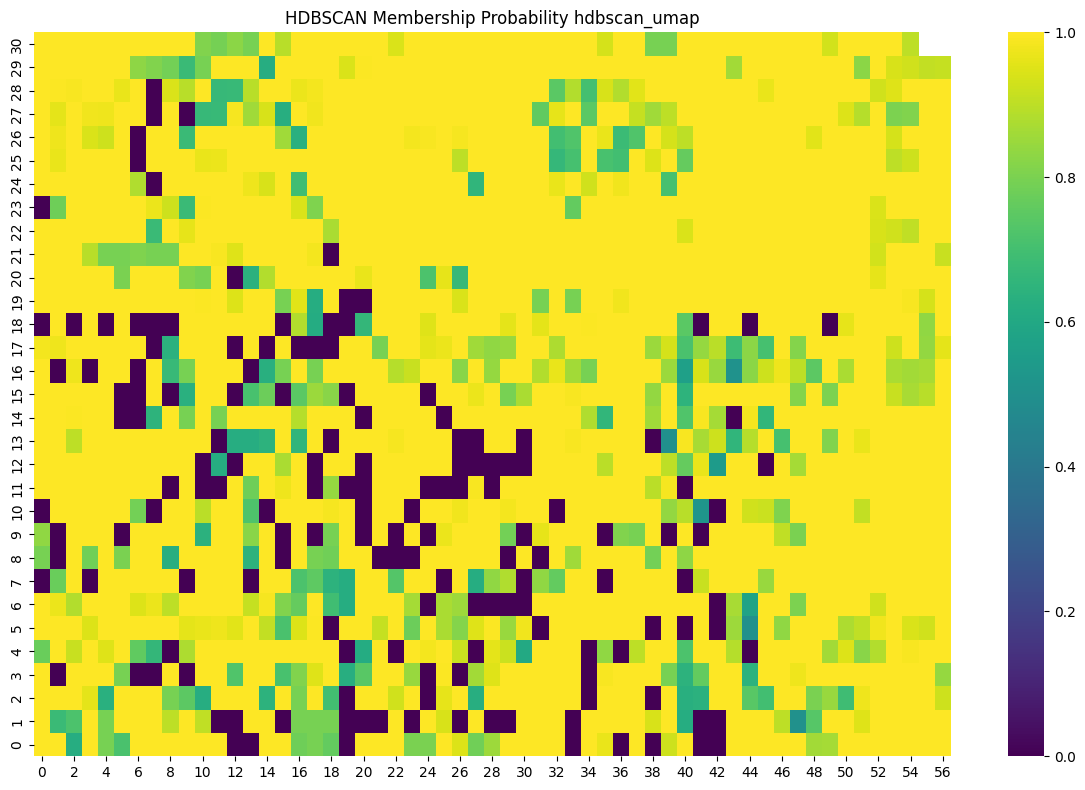

In [39]:
# Cluster embeddings and plot cluster map (57 samples per row)
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# ensure embeddings present
if 'embeddings' not in globals():
    raise RuntimeError('Run the embedding extraction cell first to populate `embeddings`.')
emb_arr = np.vstack(embeddings)


# # 1. pick number of clusters: prefer number of unique labels if available
# try:
#     n_clusters = int(np.unique(y).size)
# except Exception:
#     n_clusters = min(6, emb_arr.shape[0])

# # run KMeans (MiniBatch can be used for large data)
# kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# label = 'k_means'
# clusters = kmeans.fit_predict(emb_arr)
####
 

# 2.
# clusterer = hdbscan.HDBSCAN(
#     min_cluster_size=50,
#     min_samples=14,
#     metric='euclidean'
# )

# label = 'hdbscan'
# clusters = clusterer.fit_predict(emb_arr)
####

# 3.
# emb_pca = PCA(n_components=10).fit_transform(emb_arr)
# clusterer = hdbscan.HDBSCAN(
#     min_cluster_size=40,
#     min_samples=8,
#     metric='euclidean'
# )

# label = 'hdbscan_pca'
# clusters = clusterer.fit_predict(emb_pca)
####

# 4.
emb_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(emb_arr)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric='euclidean'
)
label = 'hdbscan_umap'
clusters = clusterer.fit_predict(emb_umap)
####

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print(f"Gefundene Cluster: {n_clusters}")
print(f"Noise-Punkte: {(clusters == -1).sum()}")

# map clusters back to grid with width=57
width = 57
pad = (-len(clusters)) % width
clusters_padded = np.pad(clusters.astype(float), (0, pad), constant_values=np.nan)
cluster_map = clusters_padded.reshape(-1, width)

plt.figure(figsize=(12,8))
ax = sns.heatmap(cluster_map, cmap='tab20', cbar=True, linecolor='white', linewidths=0.01)
ax.invert_yaxis()
plt.title(f'Cluster map {label} (n_clusters={n_clusters})')
plt.xlabel('x index (samples along row)')
plt.ylabel('y index (rows of sample grid)')
plt.tight_layout()
plt.show()

# save cluster assignments
#np.save('clusters.npy', clusters)

probabilities = clusterer.probabilities_

prob_map = np.pad(
    probabilities,
    (0, pad),
    constant_values=np.nan
).reshape(-1, width)

plt.figure(figsize=(12,8))

ax = sns.heatmap(
    prob_map,
    cmap='viridis'
)

ax.invert_yaxis()

if label != 'k_means':
    plt.title(f'HDBSCAN Membership Probability {label}')
    plt.tight_layout()
    plt.show()

best and worst label found via symmetry and noise

In [21]:
def symmetry_score(img):

    w = img.shape[1]
    mid = w // 2

    left = img[:, :mid]

    if w % 2 == 0:
        right = img[:, mid:]
    else:
        right = img[:, mid+1:]

    right = np.flip(right, axis=1)

    min_w = min(left.shape[1], right.shape[1])

    left = left[:, :min_w]
    right = right[:, :min_w]

    diff = np.mean(np.abs(left - right))

    return diff

In [23]:
from scipy.ndimage import laplace

def sharpness_score(img):

    return np.var(laplace(img))

In [24]:
cluster_symmetry = {}
cluster_sharpness = {}

for c in np.unique(clusters):

    idxs = np.where(clusters == c)[0]

    scores = []

    for idx in idxs:

        img = full_dataset._data[:,:,idx]

        scores.append(symmetry_score(img))

    cluster_symmetry[c] = np.mean(scores)

print(f'Symmetrie: {cluster_symmetry}')

for c in np.unique(clusters):

    idxs = np.where(clusters == c)[0]

    scores = []

    for idx in idxs:

        img = full_dataset._data[:,:,idx]

        scores.append(sharpness_score(img))

    cluster_sharpness[c] = np.mean(scores)

print(f'Schärfe: {cluster_sharpness}')

goodness = {}
for c in np.unique(clusters):
    sym = cluster_symmetry[c]
    sharp = cluster_sharpness[c]
    goodness[c] = sym * sharp
best_cluster = max(goodness, key=goodness.get)
worst_cluster = min(goodness, key=goodness.get)
max_asym = max(cluster_symmetry, key=cluster_symmetry.get)

print("Bestes Cluster:", best_cluster)
print("Schlechtestes Cluster:", worst_cluster)


Symmetrie: {np.int64(-1): np.float32(2.8687556), np.int64(0): np.float32(6.342283), np.int64(1): np.float32(5.1848865), np.int64(2): np.float32(4.134101), np.int64(3): np.float32(1.2996172), np.int64(4): np.float32(0.9414176), np.int64(5): np.float32(0.3806828), np.int64(6): np.float32(3.8249834), np.int64(7): np.float32(2.6447644)}
Schärfe: {np.int64(-1): np.float32(203.79778), np.int64(0): np.float32(503.432), np.int64(1): np.float32(395.0678), np.int64(2): np.float32(300.39954), np.int64(3): np.float32(62.144558), np.int64(4): np.float32(40.798187), np.int64(5): np.float32(12.324463), np.int64(6): np.float32(270.8997), np.int64(7): np.float32(166.1501)}
Bestes Cluster: 0
Schlechtestes Cluster: 5
